In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def create_dataset_1(m1,s1,nb_samples_1,m2,s2,nb_samples_2):
  """
  """
  dim=len(m1)
  samples=np.vstack([np.random.normal(m1,s1,[nb_samples_1,dim]),np.random.normal(m2,s2,[nb_samples_2,dim])])
  classes=nb_samples_1*[1]
  classes.extend(nb_samples_1*[0])
  df = pd.DataFrame({'x1': samples[:,0],'x2': samples[:,1],'class':classes})
  color_map={1:'r',0:'b'}
  df['color']=df['class'].apply(lambda x:color_map[x])
  return df

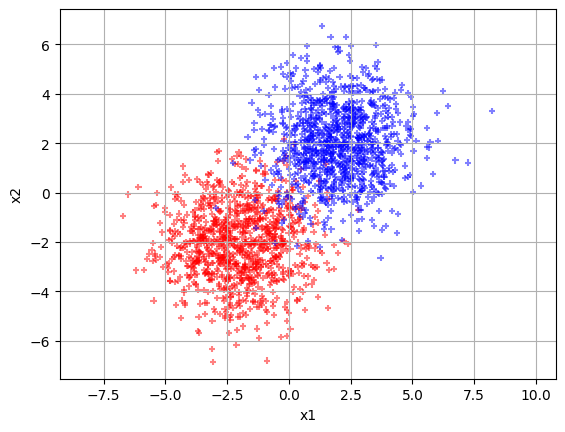

In [32]:
train_df=create_dataset_1(m1=[-2,-2.],s1=[1.5,1.5],nb_samples_1=1000,m2=[2,2.],s2=[1.5,1.5],nb_samples_2=1000)
ax = train_df.plot.scatter(x='x1',y='x2',c='color',marker='+',alpha=.5)
ax.grid('on')
ax.axis('equal')
plt.show()

In [33]:
train_samples = train_df[['x1','x2']].values.astype(np.float32)
train_targets = train_df[['class']].values.astype(np.float32)

# Logistic regression with scikitlearn

In [37]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0)
clf = clf.fit(train_samples, train_targets.squeeze())

preditions = clf.predict_proba(train_samples)

# Logistic regression with Tensorflow

In [18]:
import tensorflow as tf

def create_logistic_regression_model(input_dim):
   '''
   Create a logistic regression model
   Inputs:
   input_dim: input dimention
   Outputs:
   model: logistic regression model
   '''
   inputs = tf.keras.Input(shape=(input_dim,))
   outputs = tf.keras.layers.Dense(units=1,activation='sigmoid',name='prediction_layer')(inputs)
   model = tf.keras.Model(inputs,outputs,name='logistic_regression')
   return model

In [20]:

input_dim = train_samples.shape[1]
model=create_logistic_regression_model(input_dim=input_dim)

learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate)
model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

nb_epochs = 200
history = model.fit(train_samples,train_targets,batch_size=256,epochs=nb_epochs)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9677 - loss: 0.1107  
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9685 - loss: 0.1078 
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9628 - loss: 0.1129 
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9651 - loss: 0.1077 
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9641 - loss: 0.1076 
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9699 - loss: 0.1068 
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9662 - loss: 0.1086 
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9687 - loss: 0.1039 
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9649 - loss: 0.1077 
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9709 - loss: 0.1009 
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9719 - loss: 0.0997 
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9692 - lo

In [ ]:
weights=model.layers[1].get_weights()
w0=weights[1][0]
w1=weights[0][0]
w2=weights[0][1]

print(f"w0={w0} w1={w1} w2={w2}")

In [28]:
def line_points(a, b, c):
    """
    Draw the line ax + by + c = 0.
    Args:
        a: Coefficient of x.
        b: Coefficient of y.
        c: Constant term.
    """
    if b == 0:  # Handle the case where the line is vertical
        if a == 0:
            raise ValueError("Invalid equation: a and b cannot both be zero.")
        y = np.array([v for v in range(-5,6)])
        x = (-c / a)*np.ones((y.shape[0]))
    else:
        x = np.array([-5, 5]) # Example range: x from -5 to 5
        y = (-a * x - c) / b
    return x, y

In [6]:
test_df=create_dataset_1(m1=[-2,-2.],s1=[1.5,1.5],nb_samples_1=500,m2=[2,2.],s2=[1.5,1.5],nb_samples_2=500)
test_samples=test_df[['x1','x2']].astype(np.float32)
test_targets=np.array(test_df[['class']].astype(np.float32))
predictions=model.predict(test_samples)

predicted_classes=[int(pred[0]>0.5) for pred in predictions]
color_map={1:'r',0:'b'}
prediction_color=[color_map[c] for c in predicted_classes]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


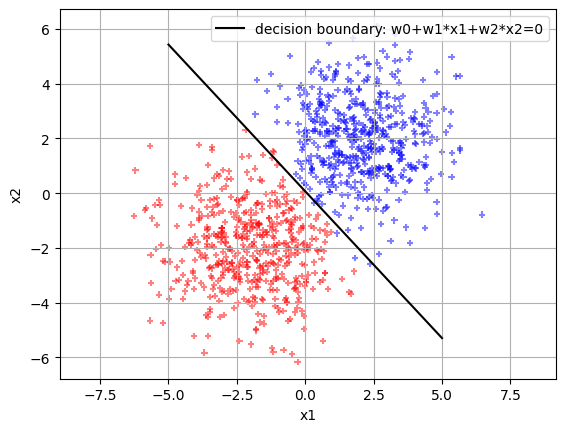

In [29]:
x,y=line_points(a=w1,b=w2,c=w0)

ax = test_df.plot.scatter(x='x1',y='x2',marker='+',c=prediction_color,alpha=.5)
ax.plot(x,y,color='k',label=f"decision boundary: w0+w1*x1+w2*x2=0")
ax.grid('on')
ax.axis('equal')
ax.legend()
plt.show()